In [1]:
import sympy as sp
import matplotlib.pyplot as plt

# Q. 26

## (a)

In [2]:
# Population data: year -> population (millions)
data = {
    1790: 3.929, 1800: 5.308, 1810: 7.240, 1820: 9.638,
    1830: 12.866, 1840: 17.069, 1850: 23.192, 1860: 31.433,
    1870: 38.558, 1880: 50.156, 1890: 62.948, 1900: 75.996,
    1910: 91.972, 1920: 105.711, 1930: 122.775, 1940: 131.669,
    1950: 150.697
}

years = sorted(data.keys())
h = 10

print(f"{'t':>5} {'Year':>6} {'P(t)':>10} {'Q(t)':>10}")
print("-" * 35)

t_vals = []
P_vals = []
Q_vals = []

for i, year in enumerate(years):
    t = (year - 1790)         # t = 0, 10, 20, ...
    Pt = data[year]

    if i < len(years) - 1:   # Q(t) undefined for last point
        Pt_h = data[years[i + 1]]
        Qt = sp.Rational(1) / Pt * (Pt_h - Pt) / h
        Qt_float = float(Qt)
        print(f"{t:>5} {year:>6} {Pt:>10.3f} {Qt_float:>10.5f}")
        t_vals.append(t)
        P_vals.append(Pt)
        Q_vals.append(Qt_float)
    else:
        print(f"{t:>5} {year:>6} {Pt:>10.3f} {'---':>10}")

    t   Year       P(t)       Q(t)
-----------------------------------
    0   1790      3.929    0.03510
   10   1800      5.308    0.03640
   20   1810      7.240    0.03312
   30   1820      9.638    0.03349
   40   1830     12.866    0.03267
   50   1840     17.069    0.03587
   60   1850     23.192    0.03553
   70   1860     31.433    0.02267
   80   1870     38.558    0.03008
   90   1880     50.156    0.02550
  100   1890     62.948    0.02073
  110   1900     75.996    0.02102
  120   1910     91.972    0.01494
  130   1920    105.711    0.01614
  140   1930    122.775    0.00724
  150   1940    131.669    0.01445
  160   1950    150.697        ---


## (b)

Regression line:  f(P) = -0.000201 * P + 0.035889


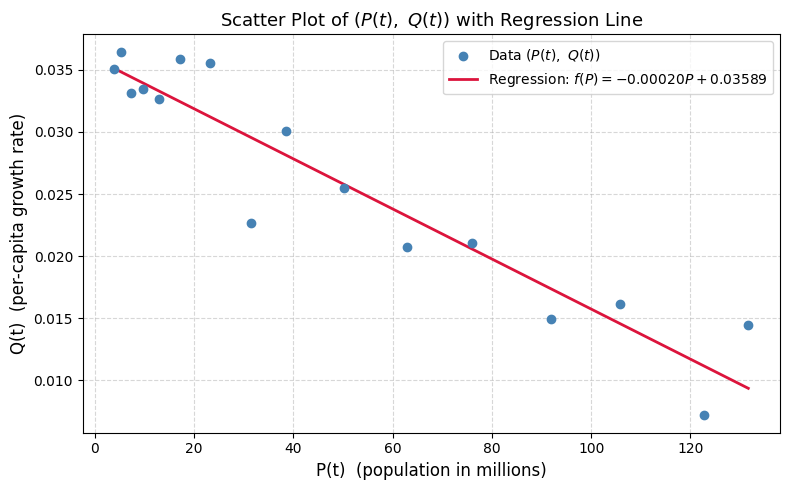

In [3]:
# Regression line using SymPy
# Q = a*P + b  →  least squares via sympy.statistics / matrix method
P_sym = sp.Matrix(P_vals)
Q_sym = sp.Matrix(Q_vals)
n     = len(P_vals)

# Build the Vandermonde-style matrix [P, 1]
A = sp.Matrix([[p, 1] for p in P_vals])

# Normal equations:  (A^T A) * [a, b]^T = A^T * Q
ATA  = A.T * A
ATQ  = A.T * Q_sym
coeffs = ATA.solve(ATQ)          # SymPy solves exactly (rational arithmetic)

a, b = float(coeffs[0]), float(coeffs[1])
print(f"Regression line:  f(P) = {a:.6f} * P + {b:.6f}")

# Plot
P_line = [min(P_vals), max(P_vals)]
Q_line = [a * p + b for p in P_line]

plt.figure(figsize=(8, 5))
plt.scatter(P_vals, Q_vals, color='steelblue', zorder=5, label='Data $(P(t),\\ Q(t))$')
plt.plot(P_line, Q_line, color='crimson', linewidth=2,
         label=f'Regression: $f(P) = {a:.5f}P + {b:.5f}$')

plt.xlabel('P(t)  (population in millions)', fontsize=12)
plt.ylabel('Q(t)  (per-capita growth rate)', fontsize=12)
plt.title('Scatter Plot of $(P(t),\\ Q(t))$ with Regression Line', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## (c)

In [4]:
# Logistic model
# dP/dt = P * f(P) = P * (aP + b) = bP + aP^2
# This is the standard logistic: dP/dt = r*P(1 - P/K)
# where r = b,  K = -b/a
r = b
K = -b / a
print("\n(c) Logistic model:  dP/dt = P*(a*P + b)")
print(f"    r (growth rate) = {float(r):.6f}")
print(f"    K (carrying cap)= {float(K):.4f} million")


(c) Logistic model:  dP/dt = P*(a*P + b)
    r (growth rate) = 0.035889
    K (carrying cap)= 178.1226 million


## (d)

In [5]:
import sympy as sp

In [ ]:
t, C1 = sp.symbols('t C1')
P = sp.Function('P')
ode = sp.Eq(P(t).diff(t), b*P(t) + a*P(t)**2)
P_sol = sp.dsolve(ode, ics={P(0):3.929})
P_sol

In [ ]:
gen_sol = sp.Eq(sp.integrate(1/(a*P(t)**2+b*P(t)), P(t)), sp.integrate(1, t) + C1)
gen_sol

In [ ]:
sp.solve(gen_sol.subs({t:0, P(t):3.929}), C1)

In [ ]:
sp.dsolve?

# Q. 29

In [11]:
m, g, t, k, C1 = sp.symbols('m g t k C1')
v = sp.Function('v')
diff_eq = sp.Eq(m*v(t).diff(t), m*g-k*v(t)**2)
diff_eq

Eq(m*Derivative(v(t), t), g*m - k*v(t)**2)

In [12]:
# vt = sp.symbols('vt')
k_sol = sp.solve(diff_eq.rhs, k)[0]
k_sol

g*m/v(t)**2

In [15]:
v_term = sp.symbols('v_term')
k_sol = k_sol.subs({v(t):v_term})
k_sol

g*m/v_term**2

In [16]:
diff_eq = diff_eq.subs({k:k_sol})

In [17]:
diff_eq

Eq(m*Derivative(v(t), t), g*m - g*m*v(t)**2/v_term**2)

In [21]:
sol = sp.dsolve(diff_eq)

In [22]:
sol

Eq(v(t), -v_term/tanh(log(exp(C1*v_term**2 - 2*g*t))/(2*v_term)))

In [28]:
v_sol = sol.subs({C1:0}).simplify()
v_sol

Eq(v(t), -v_term/tanh(log(exp(-2*g*t))/(2*v_term)))

In [29]:
s = sp.integrate(v_sol.rhs, t)
s = s.simplify()
s

-v_term*(g*t + v_term*log(tanh(log(exp(-2*g*t))/(2*v_term)) + 1) - v_term*log(tanh(log(exp(-2*g*t))/(2*v_term))))/g

In [ ]:
v_t_sym = sp.Symbol('v_t', positive=True)
s_expr = (v_t_sym**2/32)*sp.)

In [2]:
import sympy as sp

t, g, vt = sp.symbols('t g vt', positive=True)
v = sp.Function('v')

ode = sp.Eq(
    sp.diff(v(t), t),
    g*(1 - v(t)**2/vt**2)
)

# Solve WITHOUT ICs
sol = sp.dsolve(ode)

print(sol)

Eq(v(t), vt/tanh((C1*vt**2 + g*t)/vt))


In [3]:
C1 = sp.symbols('C1')

v_general = vt*sp.tanh(C1 + g*t/vt)

# Apply v(0)=0
eq_ic = sp.Eq(v_general.subs(t, 0), 0)

C1_sol = sp.solve(eq_ic, C1)

print(C1_sol)

[0, I*pi]
